# Flight Booking Price Prediction
## By: Ayush Trivedi

### Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn import metrics
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

C:\Users\ayush\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Loading the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\ayush\Downloads\Python Projects\Flight_Booking\Flight_Booking.csv")
df=df.drop(columns=['Unnamed: 0'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.shape

(300153, 11)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [5]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

### Data Visualization

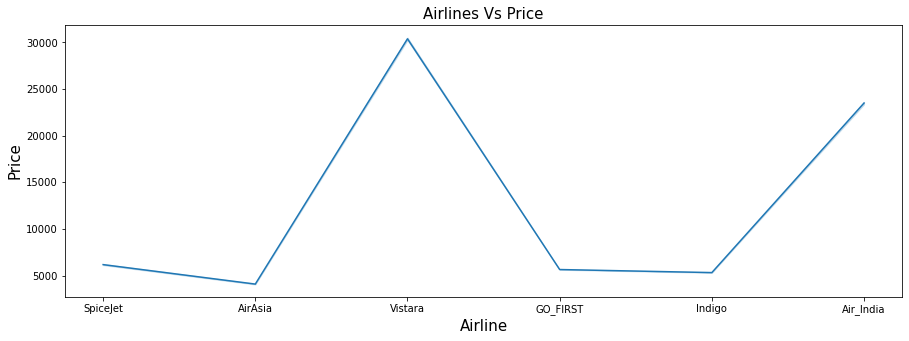

In [6]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df['airline'],y=df['price'])
plt.title('Airlines Vs Price', fontsize=15)
plt.xlabel('Airline', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.show()

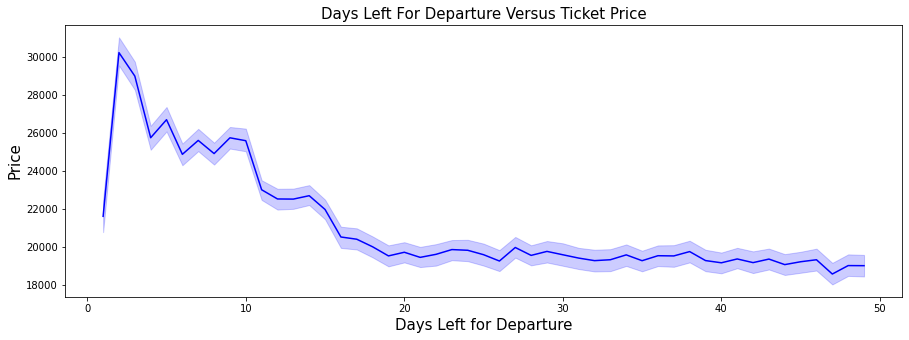

In [7]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x='days_left',y='price', color='blue')
plt.title('Days Left For Departure Versus Ticket Price', fontsize=15)
plt.xlabel('Days Left for Departure', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.show()

<AxesSubplot:xlabel='airline', ylabel='price'>

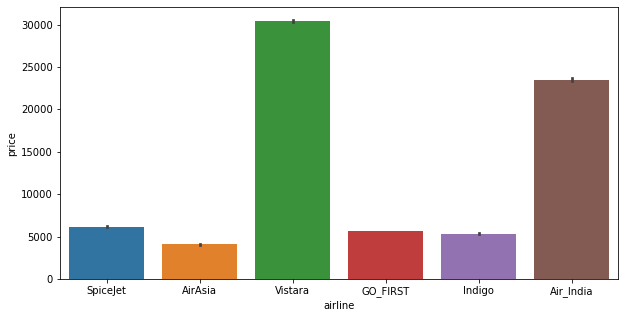

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x='airline',y='price', data=df)

<AxesSubplot:xlabel='class', ylabel='price'>

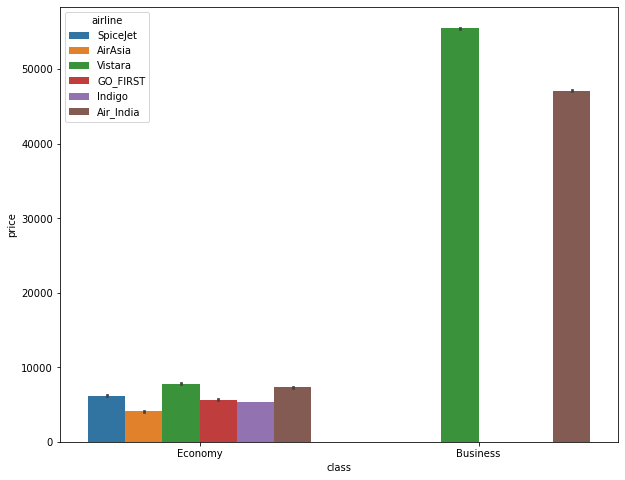

In [9]:
plt.figure(figsize=(10,8))
sns.barplot(x='class',y='price', data=df, hue='airline')

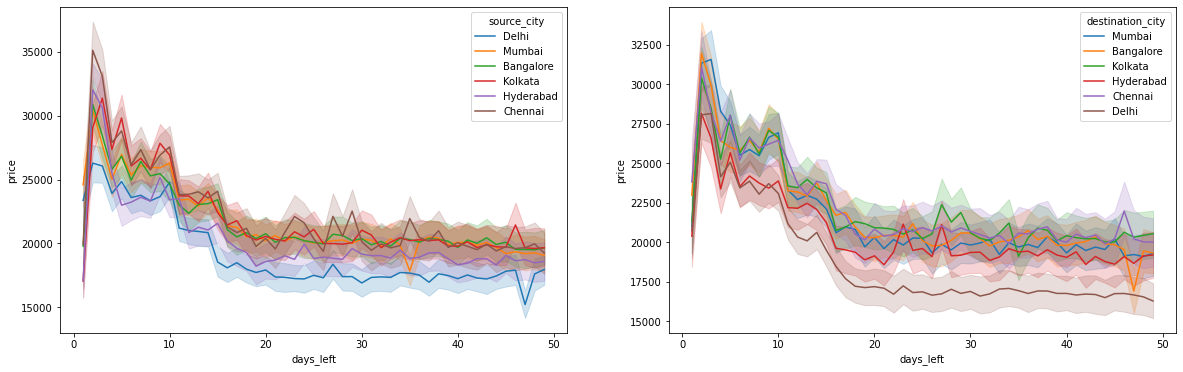

In [10]:
fig, ax=plt.subplots(1,2, figsize=(20,6))
sns.lineplot(x='days_left', y='price', data=df, hue='source_city', ax=ax[0])
sns.lineplot(x='days_left', y='price', data=df, hue='destination_city', ax=ax[1])
plt.show()

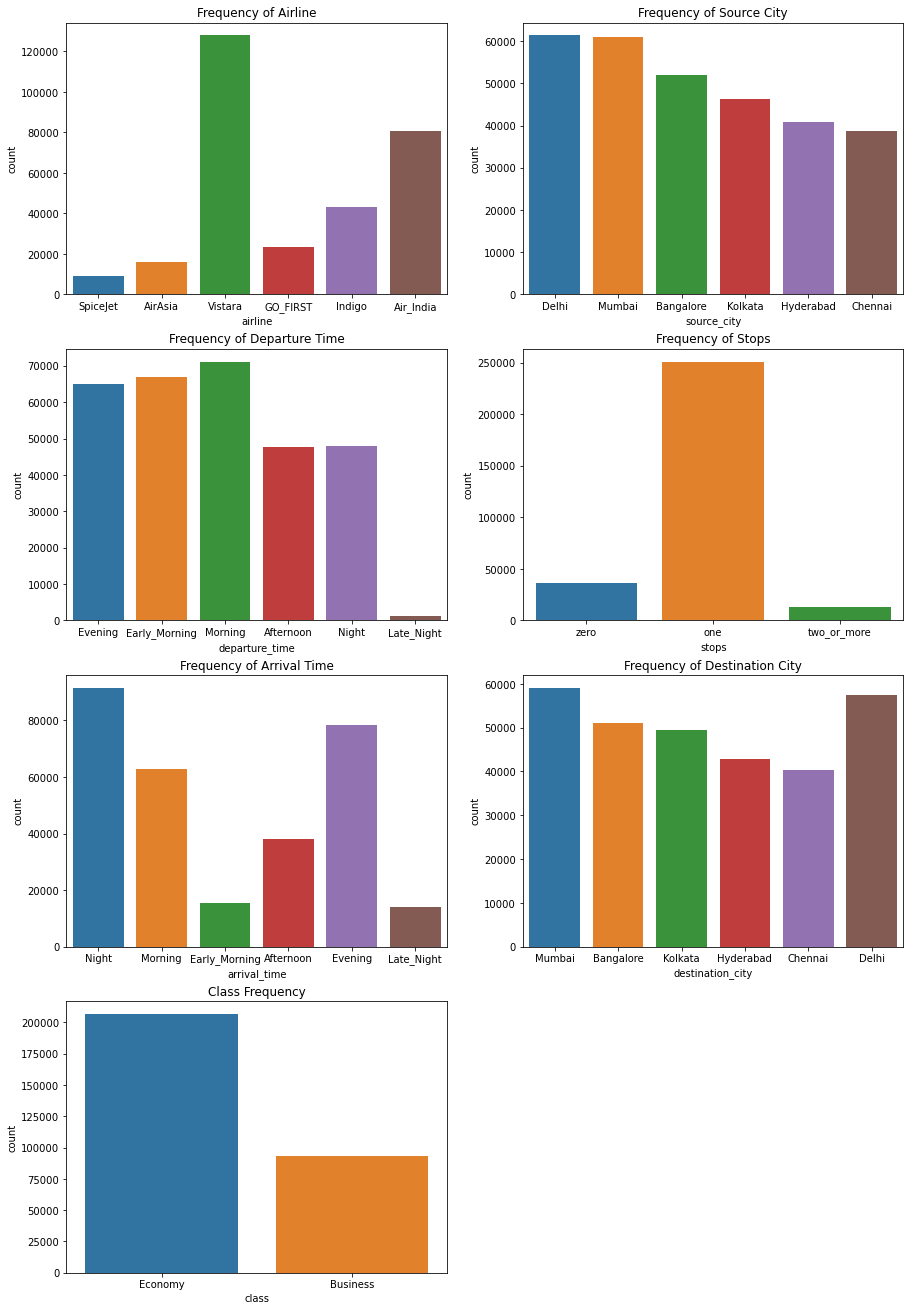

In [11]:
plt.figure(figsize=(15,23))
plt.subplot(4,2,1)
sns.countplot(x=df["airline"],data=df)
plt.title("Frequency of Airline")
plt.subplot(4,2,2)
sns.countplot(x=df["source_city"],data=df)
plt.title("Frequency of Source City")
plt.subplot(4,2,3)
sns.countplot(x=df["departure_time"],data=df)
plt.title("Frequency of Departure Time")
plt.subplot(4,2,4)
sns.countplot(x=df["stops"],data=df)
plt.title("Frequency of Stops")
plt.subplot(4,2,5)
sns.countplot(x=df["arrival_time"],data=df)
plt.title("Frequency of Arrival Time")
plt.subplot(4,2,6)
sns.countplot(x=df["destination_city"],data=df)
plt.title("Frequency of Destination City")
plt.subplot(4,2,7)
sns.countplot(x=df["class"],data=df)
plt.title("Class Frequency")
plt.show()

### One Hot Label Encoding

In [12]:
le=LabelEncoder()
df["airline"]=le.fit_transform(df["airline"])
df["flight"] = le.fit_transform(df["flight"])
df["source_city"]=le.fit_transform(df["source_city"])
df["departure_time"]=le.fit_transform(df["departure_time"])
df["stops"]=le.fit_transform(df["stops"])
df["arrival_time"]=le.fit_transform(df["arrival_time"])
df["destination_city"]=le.fit_transform(df["destination_city"])
df["class"]=le.fit_transform(df["class"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int32  
 1   flight            300153 non-null  int32  
 2   source_city       300153 non-null  int32  
 3   departure_time    300153 non-null  int32  
 4   stops             300153 non-null  int32  
 5   arrival_time      300153 non-null  int32  
 6   destination_city  300153 non-null  int32  
 7   class             300153 non-null  int32  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int32(8), int64(2)
memory usage: 16.0 MB


### Feature Selection

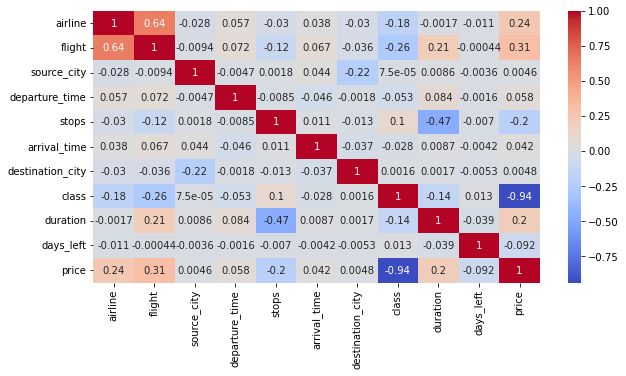

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [14]:
col_list=[]
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price')):
        col_list.append(col)
x=df[col_list]
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i)
                 for i in range(len(x.columns))]
print(vif_data)

            feature        VIF
0           airline   6.701818
1            flight  12.675046
2       source_city   2.969540
3    departure_time   2.806009
4             stops   1.437326
5      arrival_time   3.784873
6  destination_city   2.918792
7             class   2.852072
8          duration   4.754588
9         days_left   4.071591


In [15]:
df=df.drop(columns=["stops"])

In [28]:
df = df.drop(columns=["flight"])
col_list=[]
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price')):
        col_list.append(col)
x=df[col_list]
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i)
                 for i in range(len(x.columns))]
print(vif_data)

            feature       VIF
0           airline  3.370020
1       source_city  2.895803
2    departure_time  2.746255
3      arrival_time  3.632792
4  destination_city  2.857808
5             class  2.776721
6          duration  3.429344
7         days_left  3.950132


### Standardization and Linear Regression

In [29]:
x=df.drop(columns=["price"])
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
difference=pd.DataFrame(np.c_[y_test,y_pred],columns=["Actual_Value","Predicted_Value"])
difference


,Actual_Value,Predicted_Value
0,7366.0,4673.755319
1,64831.0,51713.744720
2,6195.0,6610.897658
3,60160.0,55489.844234
4,6578.0,5120.342596
...,...,...
60026,5026.0,4960.777767
60027,3001.0,4693.865426
60028,6734.0,4974.962678
60029,5082.0,2729.650066


In [30]:
print("r2_score:",r2_score(y_test,y_pred))
mean_abs_error=metrics.mean_absolute_error(y_test,y_pred)
print("Mean_Absolute_Error:",mean_abs_error)
print("Mean_Absolute_Percentage_Error:",mean_absolute_percentage_error(y_test,y_pred))
mean_sq_error=metrics.mean_squared_error(y_test,y_pred)
print("Mean_Sq_Error:",mean_sq_error)
root_mean_sq_error=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print("Root_Mean_Sq_Error:",root_mean_sq_error)

r2_score: 0.897752737512321
Mean_Absolute_Error: 4468.426673542108
Mean_Absolute_Percentage_Error: 0.3476580461068174
Mean_Sq_Error: 52706651.33334209
Root_Mean_Sq_Error: 7259.934664536733


C:\Users\ayush\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\ayush\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


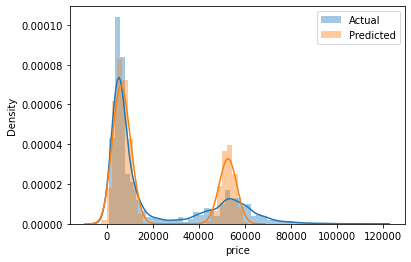

In [32]:
sns.distplot(y_test,label="Actual")
sns.distplot(y_pred,label="Predicted")
plt.legend()

### Decision Tree Regressor

In [35]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print("r2_score:",r2_score(y_test,y_pred))
mean_abs_error=metrics.mean_absolute_error(y_test,y_pred)
print("mean_abs_error:",mean_abs_error)
print("mean_absolute_percentage_error:",mean_absolute_percentage_error(y_test,y_pred))
mean_sq_error=metrics.mean_squared_error(y_test,y_pred)
print("mean_sq_error:",mean_sq_error)
root_mean_sq_error=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print("root_mean_sq_error:",root_mean_sq_error)

r2_score: 0.9745608114486924
mean_abs_error: 1218.970781762756
mean_absolute_percentage_error: 0.07742325425834219
mean_sq_error: 13113450.752175266
root_mean_sq_error: 3621.2498881153265


### Random Forest Regressor

In [36]:
rfr=RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)
print("r2_score:",r2_score(y_test,y_pred))
mean_abs_error=metrics.mean_absolute_error(y_test,y_pred)
print("mean_abs_error:",mean_abs_error)
print("mean_absolute_percentage_error:",mean_absolute_percentage_error(y_test,y_pred))
mean_sq_error=metrics.mean_squared_error(y_test,y_pred)
print("mean_sq_error:",mean_sq_error)
root_mean_sq_error=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print("root_mean_sq_error:",root_mean_sq_error)

r2_score: 0.9844951083019787
mean_abs_error: 1124.9254863719732
mean_absolute_percentage_error: 0.07344262777297887
mean_sq_error: 7992496.823935129
root_mean_sq_error: 2827.100426927761
